9장 생성 모델

In [ ]:
# 예제 9.1 오토 인코더(fashion_mnist 재구성)

#셋업
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, _), (x_test, _) = fashion_mnist.load_data()   # 레이블은 사용하지 않음

In [ ]:
# 데이터 정규화
x_train = x_train / 255
x_test = x_test / 255

In [ ]:
# 인코더 정의
class Encoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.flatten = Flatten()
        self.dense = Dense(units=latent_dim, activation='relu')

    def call(self, x):
        x = self.flatten(x)
        x = self.dense(x)
        return x

In [ ]:
# 디코더 정의
class Decoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.dense = Dense(units=28 * 28, activation="sigmoid")
        self.reshape = Reshape((28, 28))

    def call(self, x):
        x = self.dense(x)
        x = self.reshape(x)
        return x

In [ ]:
# 오토 인코더 정의
class AutoEncoder(Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def call(self, inputs):
        x = self.encoder(inputs)
        x = self.decoder(x)
        return x

# 모델 생성
model = AutoEncoder(latent_dim=32)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="mse")

In [ ]:
# 모델 학습
history = model.fit(x_train, x_train, batch_size=32, epochs=10, verbose=0)

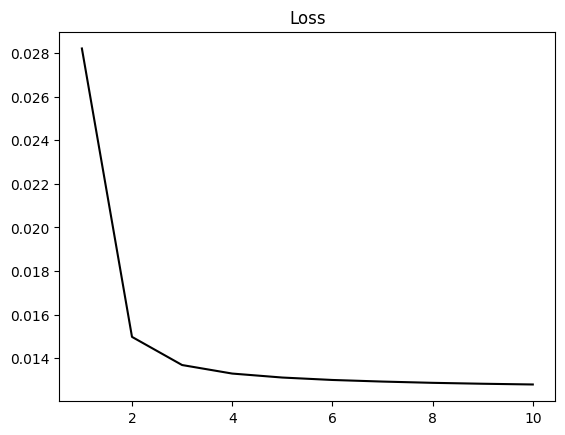

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], color="black")
plt.title("Loss")

plt.show()

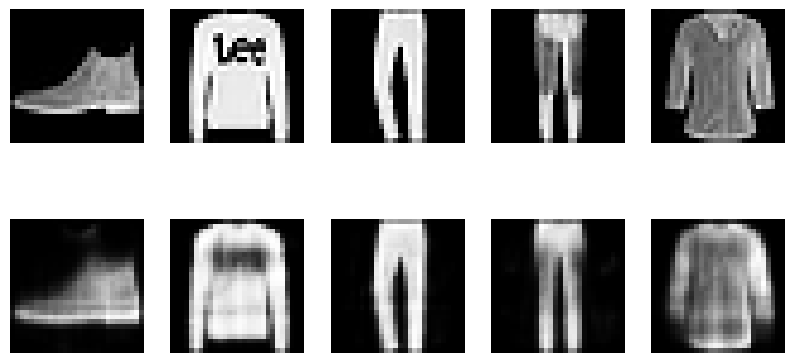

In [ ]:
# 원본 이미지/재구성 이미지 시각화
plt.figure(figsize=(10, 5))

for i in range(5):

    # 원본 이미지
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis("off")

    # 재구성 이미지
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(model(x_test)[i], cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
# 예제 9.2 VAE 사람 얼굴 생성 CelebA

# 셋업
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Layer
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import PIL
from IPython import display
import os
import zipfile
import gdown

# 데이터셋 다운로드
file_id = "1up5bN8LCE2vHigVY-Z9yY2_aKRW5jN_9"
url = f"https://drive.google.com/uc?export=download&id={file_id}"

path_zip = os.path.join(os.getcwd(), "celeba.zip")   # zip 저장 경로
path = os.path.join(os.getcwd(), "celeba")   # 압축 해제 경로

gdown.download(url, path_zip, quiet=False)   # 다운로드

with zipfile.ZipFile(path_zip, "r") as zip_ref:   # 파일 열기
    zip_ref.extractall(path)   # 압축 해제

Downloading...
From (original): https://drive.google.com/uc?export=download&id=1up5bN8LCE2vHigVY-Z9yY2_aKRW5jN_9
From (redirected): https://drive.google.com/uc?export=download&id=1up5bN8LCE2vHigVY-Z9yY2_aKRW5jN_9&confirm=t&uuid=03ab7263-e5a0-4dd3-ad62-51f6ee8e4a74
To: /content/celeba.zip
100%|██████████| 1.44G/1.44G [00:27<00:00, 52.5MB/s]


size of image: (178, 218)


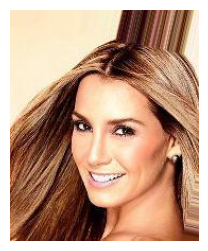

In [ ]:
# 원본 이미지 확인
image_path = "/content/celeba/img_align_celeba/000001.jpg"   # 이미지 경로 지정
image = PIL.Image.open(image_path)

print("size of image:", image.size)

plt.figure(figsize=(3, 3))
plt.imshow(image)
plt.axis("off")

plt.show()

In [ ]:
# 데이터셋 준비
dataset = tf.keras.utils.image_dataset_from_directory(
    directory="/content/celeba",   # 폴더 경로 지정
    label_mode=None,   # 레이블 사용하지 않음
    image_size=(64, 64),   # 이미지 크기(64x64)
    batch_size=32)   # 배치 크기(32)

Found 202599 files.


In [ ]:
# 소규모 CelebA 데이터셋 사용
dataset = dataset.take(313)   # 10,000개(32x313) 샘플

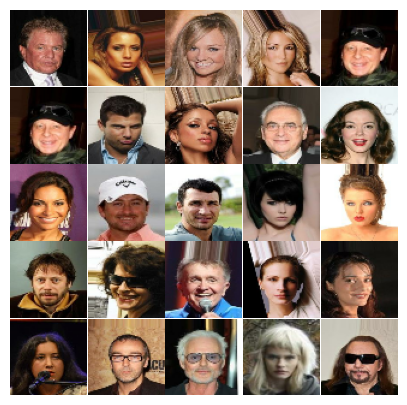

In [ ]:
# 학습 이미지 시각화
fig, axes = plt.subplots(5, 5, figsize=(5, 5))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i, ax in enumerate(axes.ravel()):
    for imgs in dataset.take(1):
        ax.imshow(imgs[i] / 255.)   # 픽셀 값 (0, 1) 변환
        ax.axis("off")

plt.show()

In [ ]:
# 이미지를 넘파이 배열로 변환
x_train = []

for batch in dataset:
    x_train.append(batch.numpy())

x_train = np.concatenate(x_train, axis=0)

print(x_train.shape)   # 학습 데이터 shape 확인

(10016, 64, 64, 3)


In [ ]:
# 정규화
x_train = x_train / 255

In [ ]:
# 인코더 정의
latent_dim = 2

inputs = Input(shape=(64, 64, 3))
x = Conv2D(32, kernel_size=3, strides=2, padding="same",
           activation="relu")(inputs)
x = Conv2D(64, kernel_size=3, strides=2, padding="same",
           activation="relu")(x)
x = Conv2D(128, kernel_size=3, strides=2, padding="same",
           activation="relu")(x)
x = Flatten()(x)
x = Dense(32, activation="relu")(x)

mu = Dense(latent_dim)(x)
log_var = Dense(latent_dim)(x)

encoder = Model(inputs, [mu, log_var])

In [ ]:
# 잠재 공간 샘플링 계층 정의
class Sampling(Layer):
    def call(self, inputs):
        mu, log_var = inputs
        epsilon = tf.random.normal(tf.shape(log_var))
        return mu + tf.exp(0.5 * log_var) * epsilon

In [ ]:
# 디코더 정의
decoder_inputs = Input(shape=(latent_dim,))
x = Dense(8 * 8 * 128, activation='relu')(decoder_inputs)
x = Reshape((8, 8, 128))(x)
x = Conv2DTranspose(128, kernel_size=3, strides=2, padding="same",
                    activation="relu")(x)
x = Conv2DTranspose(64, kernel_size=3, strides=2, padding="same",
                    activation="relu")(x)
x = Conv2DTranspose(32, kernel_size=3, strides=2, padding="same",
                    activation="relu")(x)
outputs = Conv2D(3, kernel_size=3, strides=1, padding="same",
                 activation="sigmoid")(x)

decoder = Model(decoder_inputs, outputs)

In [ ]:
# 변형 오토 인코더 정의
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.sampling = Sampling()

    def call(self, inputs):
        mu, log_var = self.encoder(inputs)
        z = self.sampling([mu, log_var])
        reconstruction = self.decoder(z)

        latent_loss = -0.5 * tf.reduce_sum(   # 잠재 손실
            1 + log_var - tf.exp(log_var) - tf.square(mu), axis=-1)
        latent_loss = tf.reduce_mean(latent_loss) / 784   # 픽셀 당 잠재 손실

        self.add_loss(latent_loss)   # 손실 = 재구성 손실 + 잠재 손실
        return reconstruction

model = VAE(encoder, decoder)

In [ ]:
# 모델 컴파일
model.compile(optimizer="adam", loss="binary_crossentropy")

In [ ]:
# 모델 학습
history = model.fit(x_train, x_train, epochs=20, batch_size=32, verbose=0)

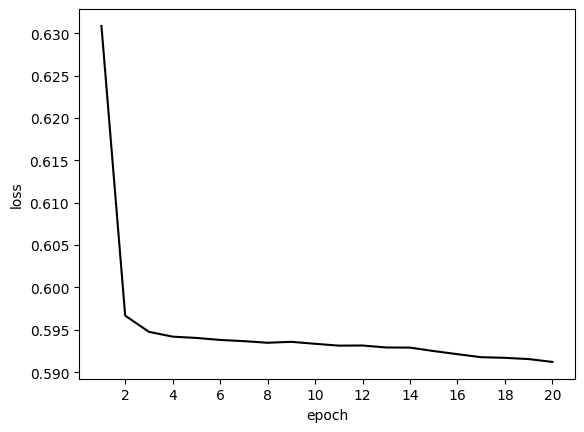

In [ ]:
# 학습 결과 시각화
plt.plot(range(1, len(history.history["loss"]) + 1),
         history.history["loss"], color="black")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.xticks(range(2, len(history.history["loss"]) + 1, 2))

plt.show()

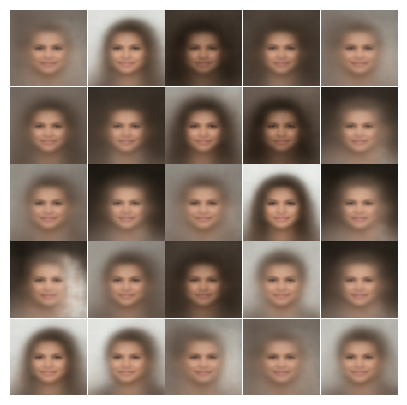

In [ ]:
# 이미지 생성
n = 25   # 이미지 수

generated_images = []
for i in range(n):
    latent_point = np.random.normal(size=(1, 2))   # 잠재 공간의 점
    decoded_image = decoder.predict(latent_point, verbose=0)
    decoded_image = decoded_image[0].reshape(64, 64,3)
    generated_images.append(decoded_image)

# 생성 이미지 시각화
fig, axes = plt.subplots(5, 5, figsize=(5, 5))
plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
# 예제 9.3 DCGAN 필기체 숫자 생성 MNIST

# 셋업
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import BatchNormalization, ReLU, LeakyReLU
from tensorflow.keras.layers import Dense, Reshape, Flatten, Dropout
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython import display

# 데이터셋 준비
(x_train, _), (_, _) = mnist.load_data()   # 레이블/테스트 데이터는 사용하지않음

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 데이터 정규화(-1 ~ !)
x_train = (x_train.astype(np.float32) - 127.5 ) / 127.5

# 2차원 이미지를 3차원으로 변환
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

print(x_train.shape)

(60000, 28, 28, 1)


In [ ]:
# 소규모 MNIST 데이터셋 생성
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(32)

x_train = x_train.take(200)   # 6,400개(200x32) 샘플

In [ ]:
# 생성자 정의
generator_inputs = Input(shape=(100, ))   # 랜덤 벡터
x = Dense(7 * 7 * 128)(generator_inputs)
x = BatchNormalization()(x)
x = ReLU()(x)
x = Reshape((7, 7, 128))(x)

x = Conv2DTranspose(64, kernel_size=4, strides=2, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

x = Conv2DTranspose(32, kernel_size=4, strides=2, padding="same")(x)
x = BatchNormalization()(x)
x = ReLU()(x)

generator_outputs = Conv2DTranspose(1, kernel_size=4, strides=1, padding="same",
                    activation="tanh")(x)

generator = Model(generator_inputs, generator_outputs, name="generator")

In [ ]:
# 판별자 정의
discriminator_inputs = Input(shape=(28, 28, 1))
x = Conv2D(32, kernel_size=4, strides=2, padding="same")(discriminator_inputs)
x = LeakyReLU(negative_slope=0.2)(x)

x = Conv2D(64, kernel_size=4, strides=2, padding="same")(x)
x = BatchNormalization()(x)
x = LeakyReLU(negative_slope=0.2)(x)

x = Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
x = BatchNormalization()(x)
x = LeakyReLU(negative_slope=0.2)(x)

x = Flatten()(x)
x = Dropout(0.2)(x)
discriminator_outputs = Dense(1, activation="sigmoid")(x)

discriminator = Model(discriminator_inputs, discriminator_outputs,
                      name="discriminator")

In [ ]:
# 하이퍼파라미터 설정
batch_size = 32   # 배치 크기
latent_dim = 100   # 랜덤 벡터 차원
num_generate = 100   # 생성할 이미지 수
seed = tf.random.normal([num_generate, latent_dim])   # 생성자 학습 시작 입력

# 손실 함수 설정
bce_loss = tf.keras.losses.BinaryCrossentropy()

# 옵티마이저 설정
g_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [ ]:
# 학습 루프 함수 정의
@tf.function   # 함수를 그래프로 변환하여 속도 향상
def train_step(images):
    noise = tf.random.normal([batch_size, latent_dim])   # 랜덤 벡터

    # 판별자 학습
    with tf.GradientTape() as tape:   # 자동 미분 수행
        real_output = discriminator(images, training=True)
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=True)

        real_loss = bce_loss(tf.ones_like(real_output), real_output)
        fake_loss = bce_loss(tf.zeros_like(fake_output), fake_output)
        d_loss = real_loss + fake_loss

    d_gradient = tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(
        zip(d_gradient, discriminator.trainable_variables))

    # 생성자 학습
    with tf.GradientTape() as tape:   # 자동 미분 수행
        fake_images = generator(noise, training=True)
        fake_output = discriminator(fake_images, training=True)
        g_loss = bce_loss(tf.ones_like(fake_output), fake_output)

    g_gradient = tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(
        zip(g_gradient, generator.trainable_variables))

In [ ]:
# 이미지 생성/저장 함수 정의
def generate_save_images(model, epoch, inputs):
    prediction = model(inputs, training=False)
    min = tf.reduce_min(prediction)
    max = tf.reduce_max(prediction)
    prediction = (prediction - min) / (max - min)  # 픽셀 값(0 ~ 1)

    fig = plt.figure(figsize=(5, 5))
    plt.subplots_adjust(wspace=0.01, hspace=0.01)

    for i in range(prediction.shape[0]):
        plt.subplot(10, 10, i + 1)
        plt.imshow(prediction[i], cmap="gray")
        plt.axis("off")
    plt.savefig(f"image at epoch {epoch}.png")
    plt.show()

In [ ]:
# 학습 함수 정의
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # 에포크마다 이미지 생성
        display.clear_output(wait=True)

        print(f"Generated Images at Epoch {epoch + 1}")

        generate_save_images(generator, epoch + 1, seed)

Generated Images at Epoch 50


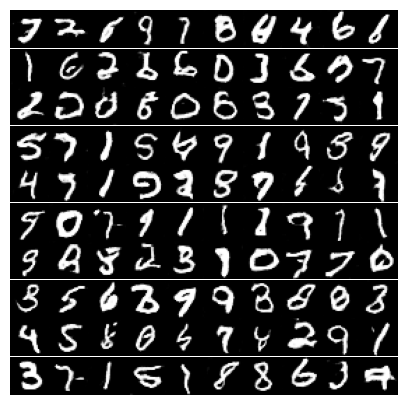

In [ ]:
# 학습(이미지 생성)
train(x_train, epochs=50)

In [ ]:
# 예제 9.4 스타일 전이(TensorFlowHub)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 셋업
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 콘텐츠 이미지(사진)/스타일 이미지(칸딘스키 구성8) 준비
content_path = "/content/drive/MyDrive/Datasets/충북대학교.jpg"   # 경로 지정
content_image = Image.open(content_path)

style_path = tf.keras.utils.get_file(   # Wikimedia Commons에서 다운로드
    "Composition8.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/"
    "0/02/Kandinsky_-_Composition_8%2C_1923.jpg")
style_image = Image.open(style_path)

218875/218875 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


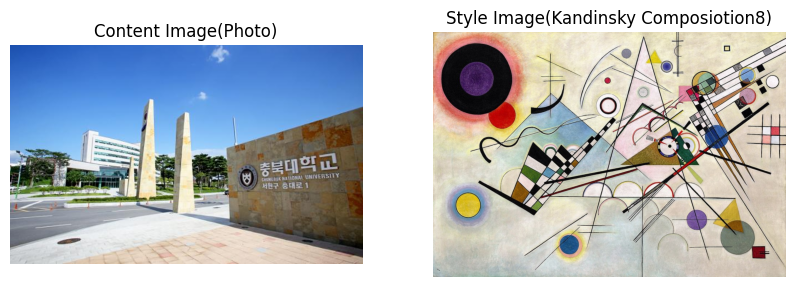

In [ ]:
# 콘텐츠 이미지/스타일 이미지 시각화
plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Content Image(Photo)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Image(Kandinsky Composiotion8)")
plt.axis("off")

plt.show()

In [ ]:
# 스타일 이미지 크기 조정
width, height = content_image.size
style_image = tf.image.resize(style_image, (height, width))

# 이미지를 배열로 변환하고 정규화
content_image = np.array(content_image, dtype=np.float32) / 255.
style_image = np.array(style_image, dtype=np.float32) / 255.

# 배치 차원 추가
content_image = np.expand_dims(content_image, axis=0)
style_image = np.expand_dims(style_image, axis=0)

print(f"shape of content image: {content_image.shape}")
print(f"shape of style image: {style_image.shape}")

shape of content image: (1, 398, 640, 3)
shape of style image: (1, 398, 640, 3)


In [ ]:
# 스타일 전이 모델 다운로드
url = "https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2"

model = hub.load(url)

In [ ]:
# 스타일 전이 이미지 생성
outputs = model(tf.constant(content_image), tf.constant(style_image))
stylized_image = outputs[0]   # 출력 리스트에서 첫 번째 텐서 선택
stylized_image = tf.squeeze(stylized_image, axis=0)   # 배치 차원 축소

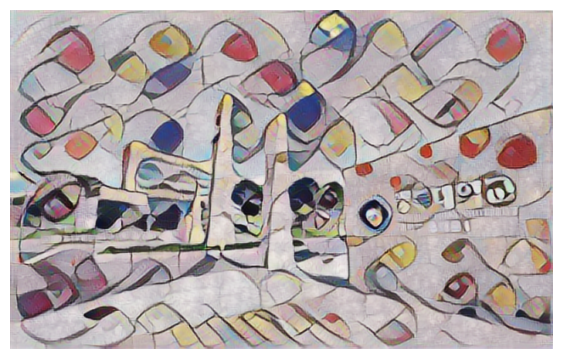

In [ ]:
# 스타일 전이 이미지 시각화
plt.figure(figsize=(7, 7))

plt.imshow(stylized_image)
plt.axis("off")

plt.show()

In [ ]:
# 예제 9.5 이미지 생성(허깅페이스 Stable Diffusion)

# 허깅페이스 Diffuser 설치
!pip install diffusers

In [ ]:
# 이미지 생성 파이프라인
from diffusers import StableDiffusionPipeline

generator = StableDiffusionPipeline.from_pretrained(
    "CompVis/stable-diffusion-v1-4").to(device="cuda")   # GPU 필수

  0%|          | 0/50 [00:00<?, ?it/s]

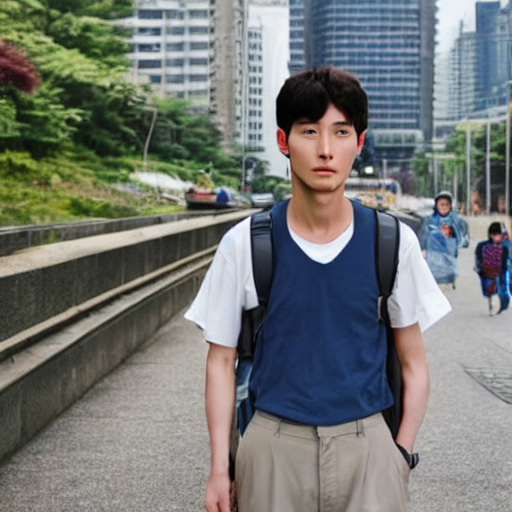

In [ ]:
# 이미지 생성
prompt = "A Korean man in his 20s"
generated_image = generator(prompt).images[0]

display(generated_image)